# Tech Challenge Fase 3 — alfabetização

Análise guiada dos artefatos produzidos por `python main.py tudo`.
Este notebook lê relatórios agregados e figuras; a implementação reproduzível está em `src/`.

**Pergunta:** contexto territorial, rede e indicadores anteriores ajudam a classificar avaliações como alfabetizadas (1) ou não alfabetizadas (0)?

Estudo retrospectivo de 2024, com classe de risco **0**. Não é previsão validada de uma safra futura.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Markdown, Image

RAIZ = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "main.py").is_file() and (p / "reports/resultados.json").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra o notebook no repositório e execute python main.py tudo primeiro.")
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

def ler(nome):
    return json.loads((RAIZ / "reports" / nome).read_text(encoding="utf-8"))

def figura(nome):
    display(Image(filename=str(RAIZ / "images" / nome), width=1000))

origem = ler("proveniencia.json")
resultados = ler("resultados.json")
interpretacao = ler("interpretacao.json")
divisao = ler("divisao.json")
assert origem["base_sha256"] == resultados["base_sha256"] == divisao["base_sha256"]
assert resultados["run_id"] == interpretacao["run_id"]
display(Markdown(f'**Execução:** {resultados["run_id"]} · **Gold:** {origem["execution_date_gold"]}'))

**Execução:** 20260908T003806585513Z · **Gold:** 2026-09-07

## 1. Base Gold e elegibilidade

A origem é exclusivamente a Gold da Fase 2. Avaliações ausentes ou sem proficiência válida não recebem rótulo de não alfabetização. A leitura valida o contrato e registra hashes para rastrear o experimento.

In [2]:
display(pd.Series(origem["elegibilidade"], name="avaliações").to_frame())
display(pd.DataFrame(origem["fontes"])[["arquivo", "linhas", "sha256"]])
display(pd.Series(origem["features_proibidas"], name="motivo da exclusão").to_frame())

,avaliações
elegivel,1851852
ausente,267772
sem_proficiencia_valida,936


,arquivo,linhas,sha256
0,gold\base_modelagem_aluno\execution_date=2026-...,2120560,21b6cb9717775adab9ce74f6b94519041e4ad4e36ac81b...


,motivo da exclusão
proficiencia,define o próprio alvo pelo corte 743
presenca,"é critério de elegibilidade, conhecido após a ..."
elegivel_modelagem,deriva da existência e validade da avaliação
motivo_exclusao_modelagem,deriva da avaliação e do rótulo
peso_aluno,não foi validado como disponível antes da aval...
meta_alfabetizacao_municipio,publicação/revisões anteriores à previsão não ...
meta_alfabetizacao_uf,publicação/revisões anteriores à previsão não ...
meta_alfabetizacao_brasil,publicação/revisões anteriores à previsão não ...
taxa_alfabetizacao_escola_anterior,códigos escolares não são estáveis entre anos
status_meta,deriva do resultado contemporâneo


São nove preditores, predominantemente municipais. Faltam Roraima, população e infraestrutura escolar. Os pagamentos Bolsa Família não representam beneficiários únicos. A taxa de presença refere-se à avaliação, não à frequência escolar anual.

In [3]:
display(pd.DataFrame({"preditores": origem["features"]}))

,preditores
0,rede
1,sigla_uf
2,regiao_brasil
3,taxa_alfabetizacao_municipio_anterior
4,taxa_presenca_municipio_anterior
5,alunos_avaliados_municipio_anterior
6,total_pagamentos_bolsa_familia_anterior
7,valor_total_bolsa_familia_anterior
8,valor_medio_pagamento_bolsa_familia_anterior


## 2. Separação antes da EDA

Escolas inteiras são reservadas para treino, validação e teste. Municípios podem aparecer em mais de um conjunto. O teste mede novas escolas na mesma edição, sem garantir generalização temporal ou para municípios novos.

In [4]:
display(pd.DataFrame(divisao["particoes"]).T.drop(columns="indices_sha256"))
assert divisao["sobreposicao_escolas"] == 0

,linhas,escolas,municipios,ufs,proporcao_nao_alfabetizados
treino,1112203,25396,4783,26,0.401862
validacao,370443,8466,3049,26,0.404286
teste,369206,8466,3067,26,0.400904


## 3. Exploração somente no treino

Hipóteses: o histórico municipal carrega persistência territorial; rede e geografia distinguem contextos; volumes financeiros têm caudas longas; ausência de histórico precisa de tratamento explícito. Todas as estatísticas desta seção vêm do treino.

,ausência no treino (%)
rede,0.000000
sigla_uf,0.000000
regiao_brasil,0.000000
taxa_alfabetizacao_municipio_anterior,23.172388
taxa_presenca_municipio_anterior,23.168432
alunos_avaliados_municipio_anterior,23.172388
total_pagamentos_bolsa_familia_anterior,0.000000
valor_total_bolsa_familia_anterior,0.000000
valor_medio_pagamento_bolsa_familia_anterior,0.000000


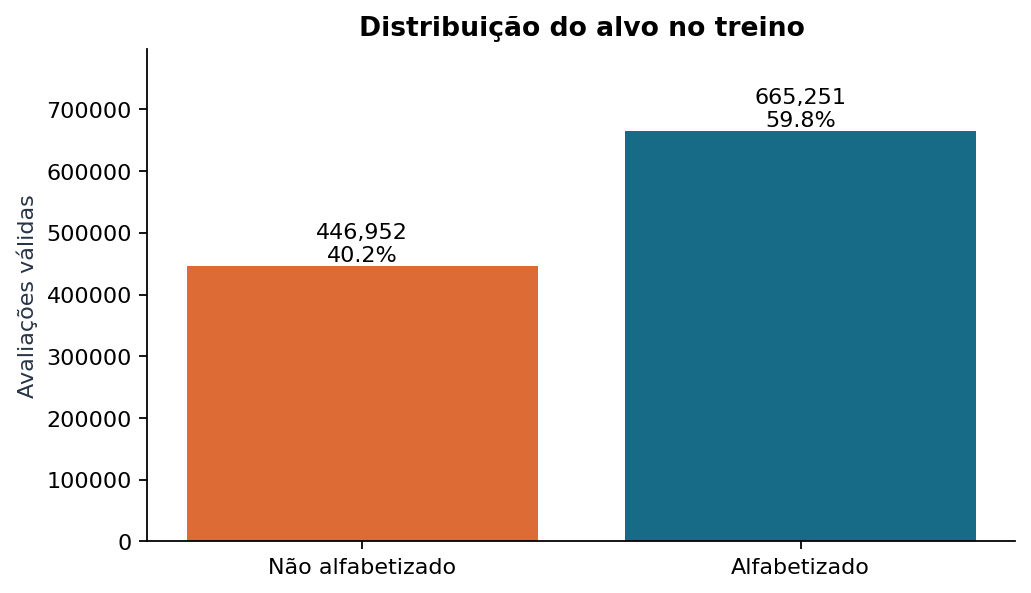

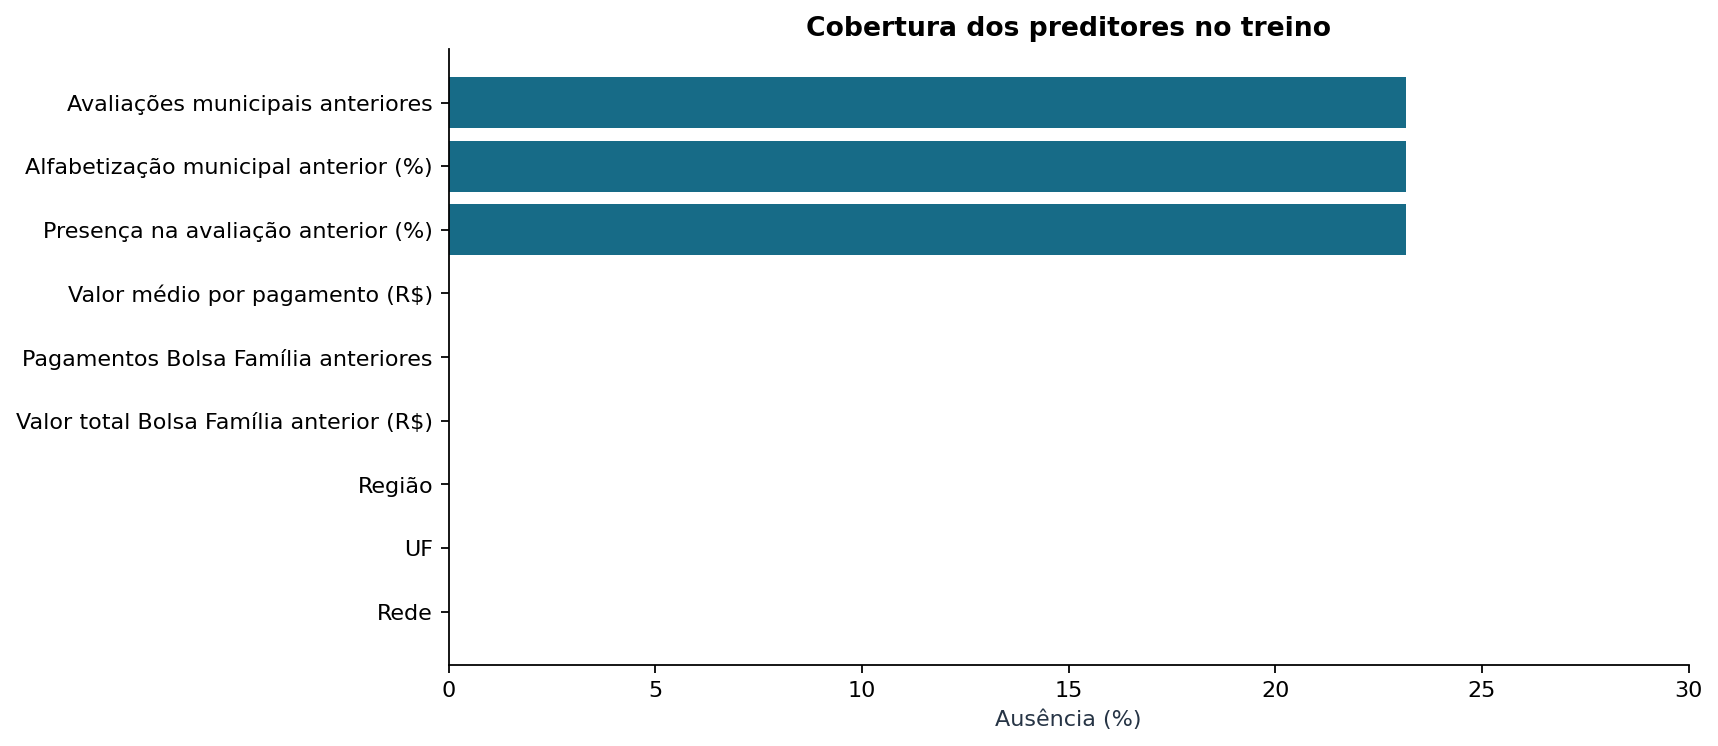

In [5]:
eda = ler("eda_resumo.json")
display(pd.Series(eda["ausencias_pct"], name="ausência no treino (%)").to_frame())
figura("eda_classes.png")
figura("eda_ausencias.png")

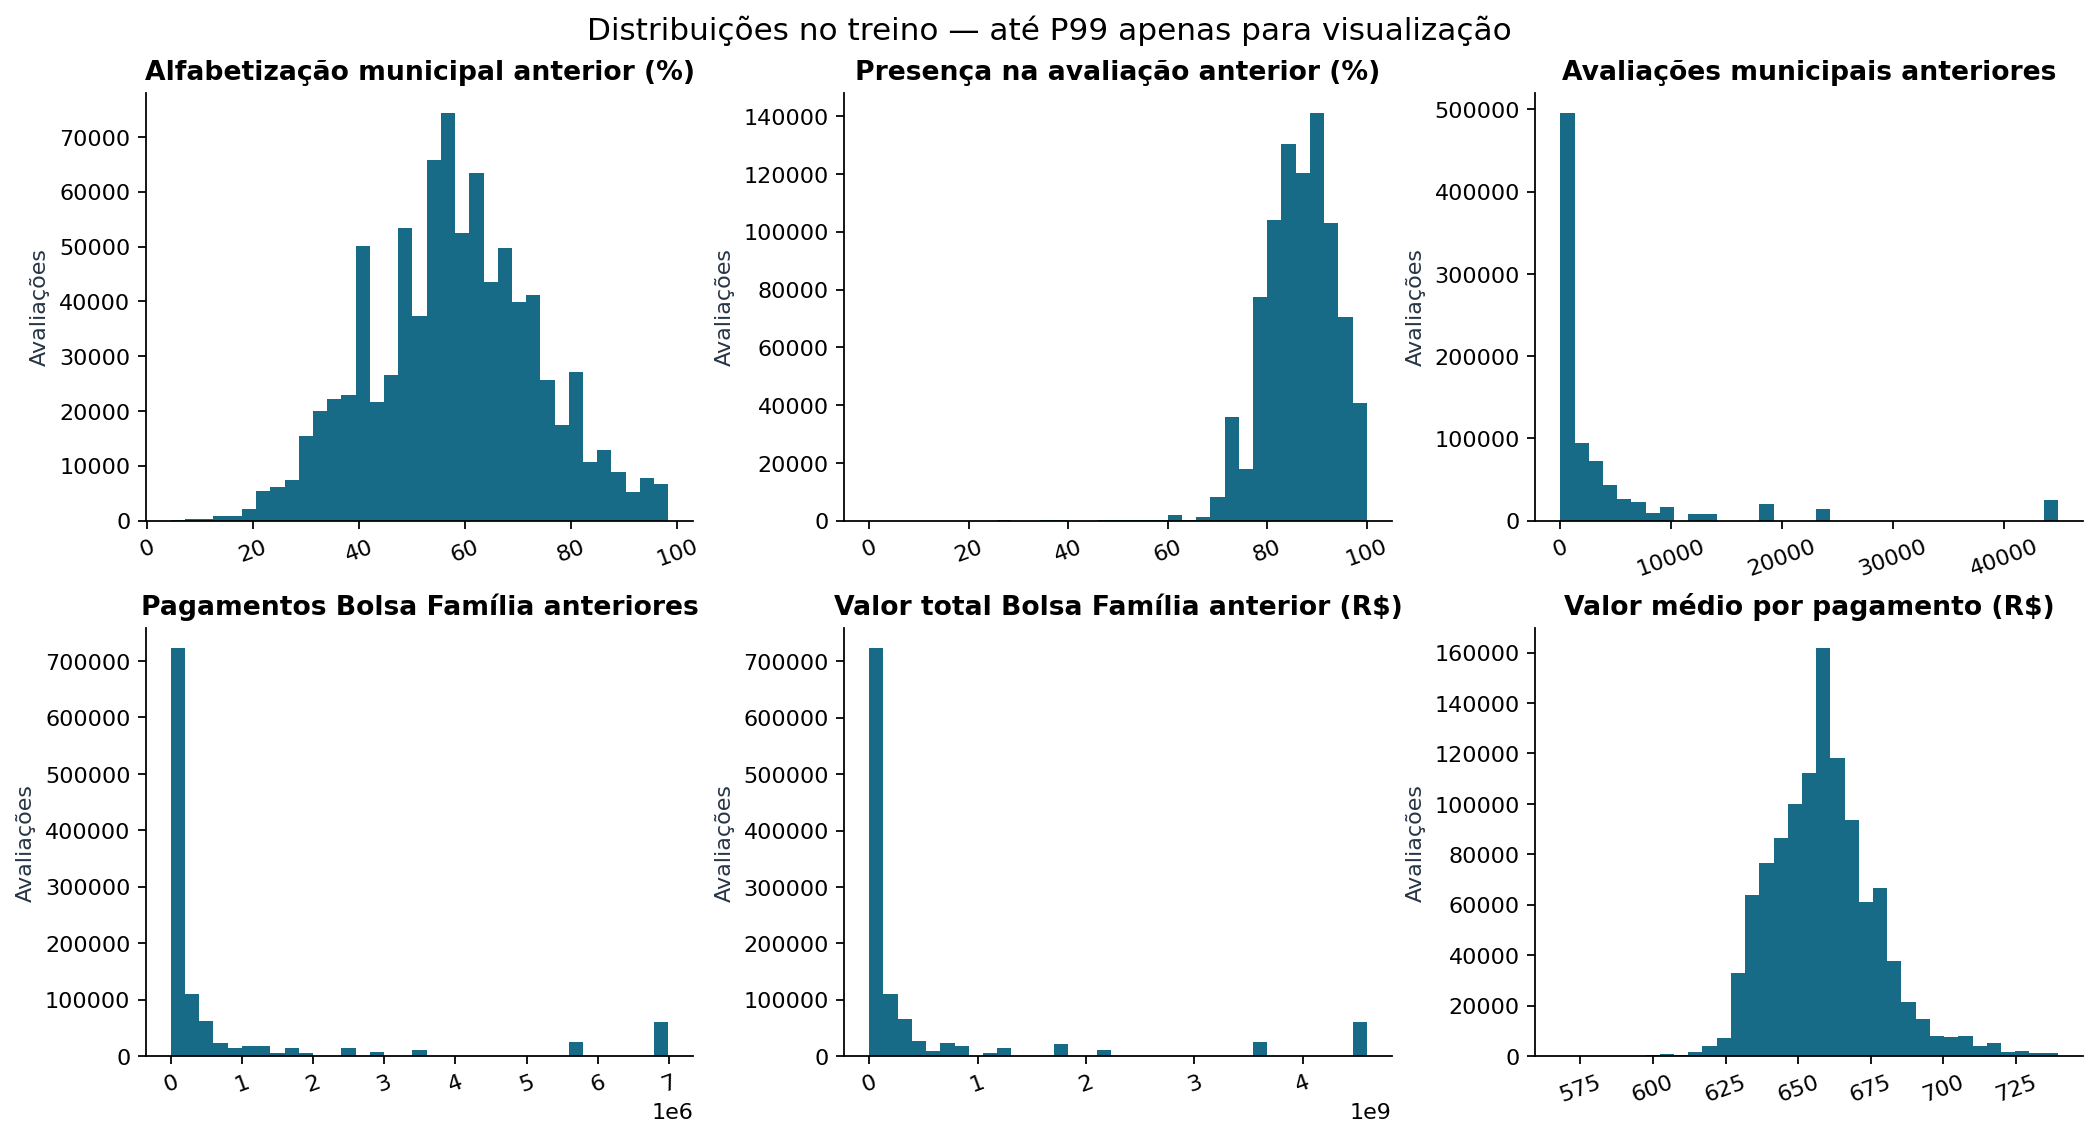

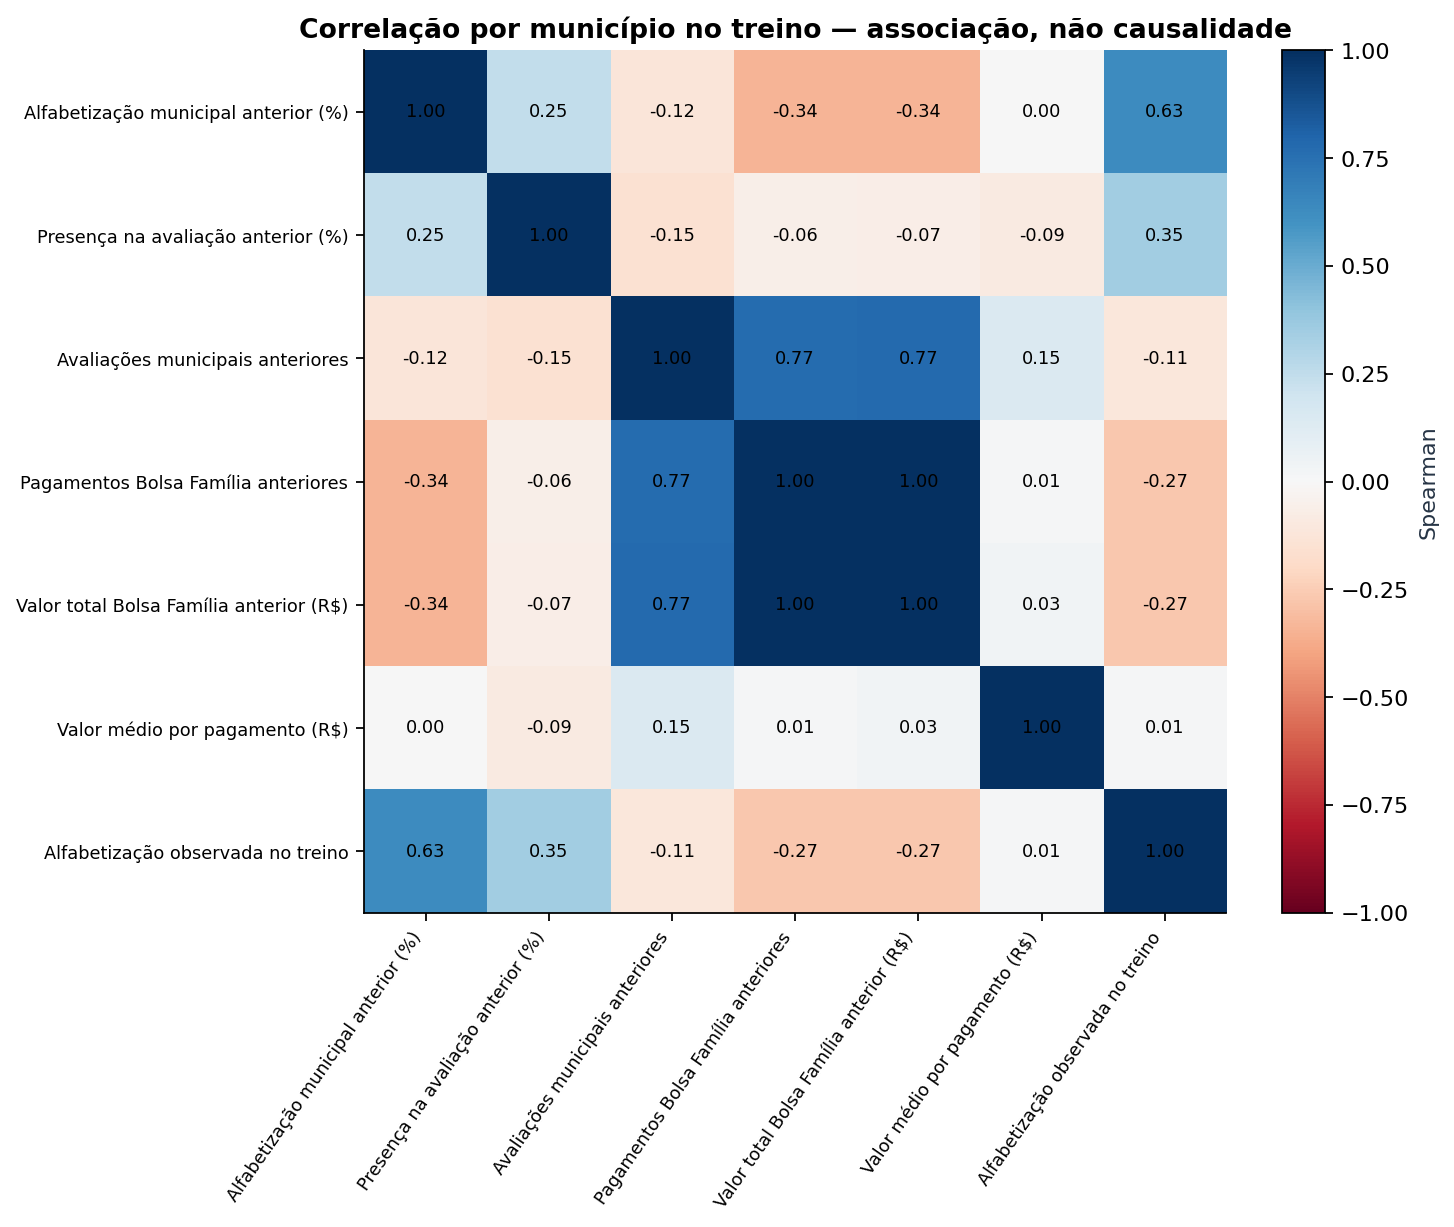

In [6]:
figura("eda_distribuicoes.png")
figura("eda_correlacoes.png")

As figuras de distribuição limitam a visualização ao P99; o pipeline mantém os valores válidos. A correlação agrega municípios do treino. Quantidade e valor de pagamentos compartilham informação, limitando a interpretação isolada desses atributos.

## 4. Pipeline e engenharia de atributos

Taxas: mediana + indicador de ausência + padronização. Volumes e valores: mediana + indicador + log1p + padronização. Categorias: imputação constante + one-hot. Todos os parâmetros são aprendidos dentro de cada dobra.

A lista explícita exclui proficiência atual, presença atual, metas de disponibilidade incerta e identificadores. O código escolar não é usado para ligar edições.

In [7]:
from src.modeling.pipelines import candidatos, GRADES

display(candidatos()["logistica"])
display(pd.Series(GRADES, name="grade de busca").to_frame())

,steps,"[('preprocessar', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('taxas', ...), ('volumes', ...), ...]"
,remainder,'drop'
,sparse_threshold,0
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


,grade de busca
logistica,"{'modelo__C': [0.1, 1.0], 'modelo__class_weigh..."
gradient_boosting,"{'modelo__max_leaf_nodes': [15, 31], 'modelo__..."


## 5. Busca, validação e escolha

A busca usa uma amostra de escolas inteiras do treino e três dobras agrupadas. Depois, cada melhor candidato é ajustado em todo o treino e avaliado na validação.

Critério fixado: maior F1 macro de validação, com preferência pela logística se a vantagem do boosting não superar 0,005. Limiar fixo 0,5. O vencedor é congelado antes do teste e reajustado com treino + validação.

In [8]:
linhas_busca = []
for nome, busca in resultados["busca"].items():
    for candidato in busca["candidatos"]:
        linhas_busca.append({"modelo": nome, **candidato})
display(pd.DataFrame(linhas_busca))
display(pd.DataFrame(resultados["validacao"]).T[["f1_macro", "recall_risco", "roc_auc"]])
display(pd.Series(resultados["selecao"], name="seleção congelada").to_frame())
assert resultados["selecao"]["teste_usado_na_selecao"] is False

,modelo,parametros,f1_treino,f1_validacao_media,f1_validacao_desvio,roc_auc_media
0,logistica,"{'modelo__C': 0.1, 'modelo__class_weight': None}",0.571823,0.568789,0.002587,0.658012
1,logistica,"{'modelo__C': 0.1, 'modelo__class_weight': 'ba...",0.598848,0.598767,0.002609,0.658096
2,logistica,"{'modelo__C': 1.0, 'modelo__class_weight': None}",0.571885,0.568291,0.003094,0.657957
3,logistica,"{'modelo__C': 1.0, 'modelo__class_weight': 'ba...",0.600913,0.601209,0.000761,0.658067
4,gradient_boosting,"{'modelo__max_leaf_nodes': 15, 'modelo__min_sa...",0.602823,0.573524,0.007877,0.655909
5,gradient_boosting,"{'modelo__max_leaf_nodes': 15, 'modelo__min_sa...",0.602470,0.575875,0.008512,0.656182
6,gradient_boosting,"{'modelo__max_leaf_nodes': 31, 'modelo__min_sa...",0.615096,0.576168,0.008430,0.652743
7,gradient_boosting,"{'modelo__max_leaf_nodes': 31, 'modelo__min_sa...",0.615488,0.578545,0.008968,0.652858


,f1_macro,recall_risco,roc_auc
baseline,0.373321,0.0,0.5
logistica,0.594511,0.646172,0.652505
gradient_boosting,0.587989,0.362141,0.662109


,seleção congelada
modelo,logistica
criterio,F1 macro de validação; tolerância 0.005 favore...
limiar_risco,0.5
teste_usado_na_selecao,False
run_id,20260908T003806585513Z


## 6. Avaliação final

As métricas no teste descrevem os três candidatos; não redefinem o vencedor. O boosting teve melhor AUC/Brier, e a logística melhor F1/recall do risco no limiar escolhido. Pesos de classe afetam calibração.

,acuracia,f1_macro,recall_risco,precisao_risco,roc_auc,brier
baseline,0.599096,0.374647,0.0,0.0,0.5,0.240182
logistica,0.601423,0.598038,0.635641,0.502293,0.656683,0.230385
gradient_boosting,0.640558,0.588389,0.354881,0.585283,0.666111,0.220369


{'metodo': 'bootstrap de escolas, percentis 2.5/97.5; modelo fixo',
 'repeticoes': 300,
 'escolas': 8466,
 'f1_macro_ic95': [0.5934009127126828, 0.6022712540530183],
 'recall_risco_ic95': [0.6208027394576558, 0.6479860643544807]}

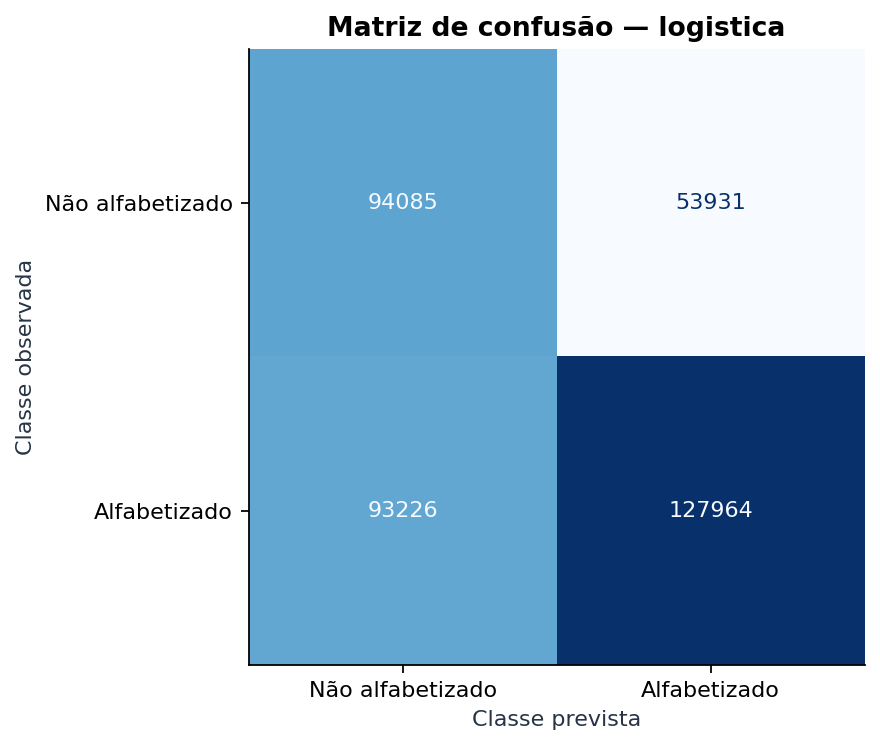

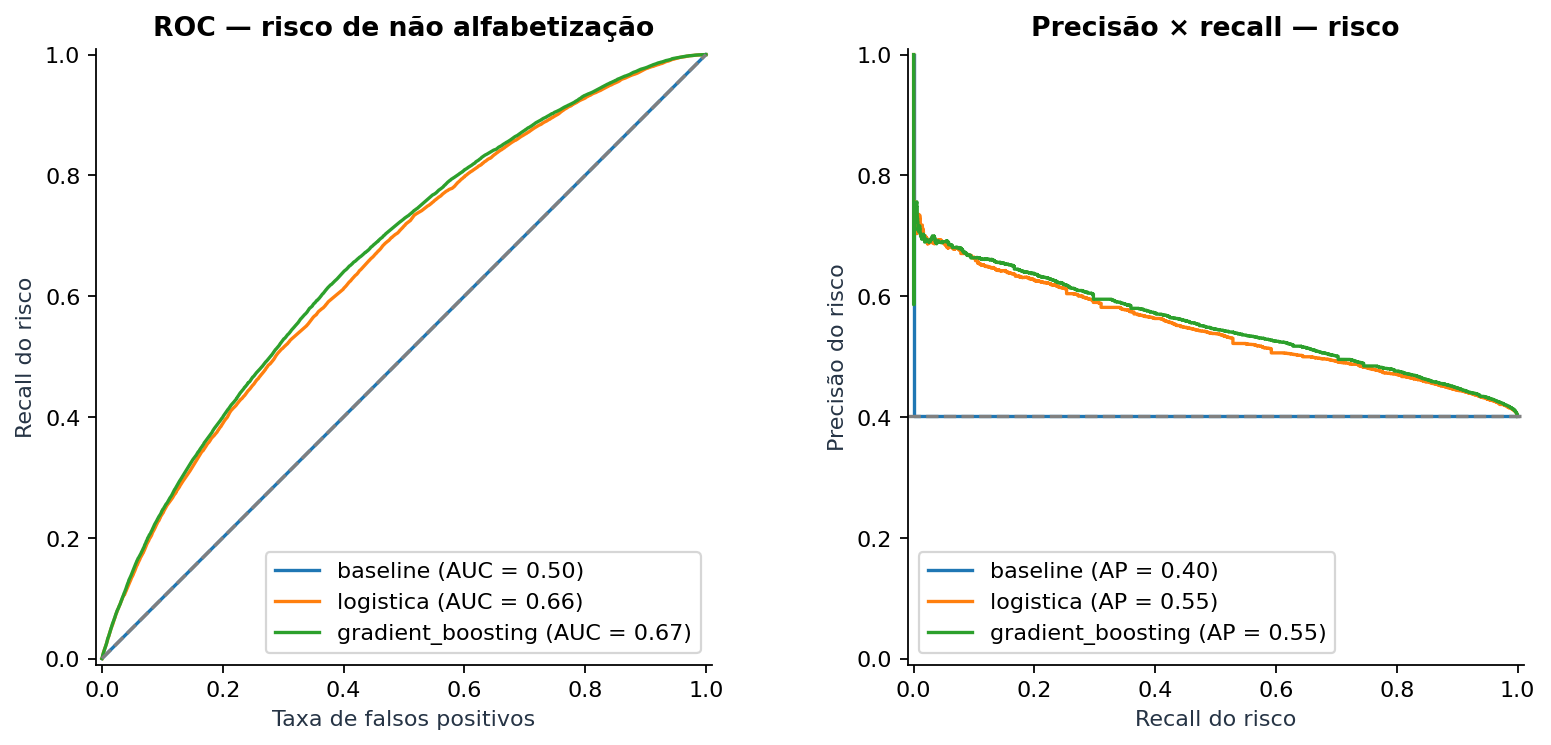

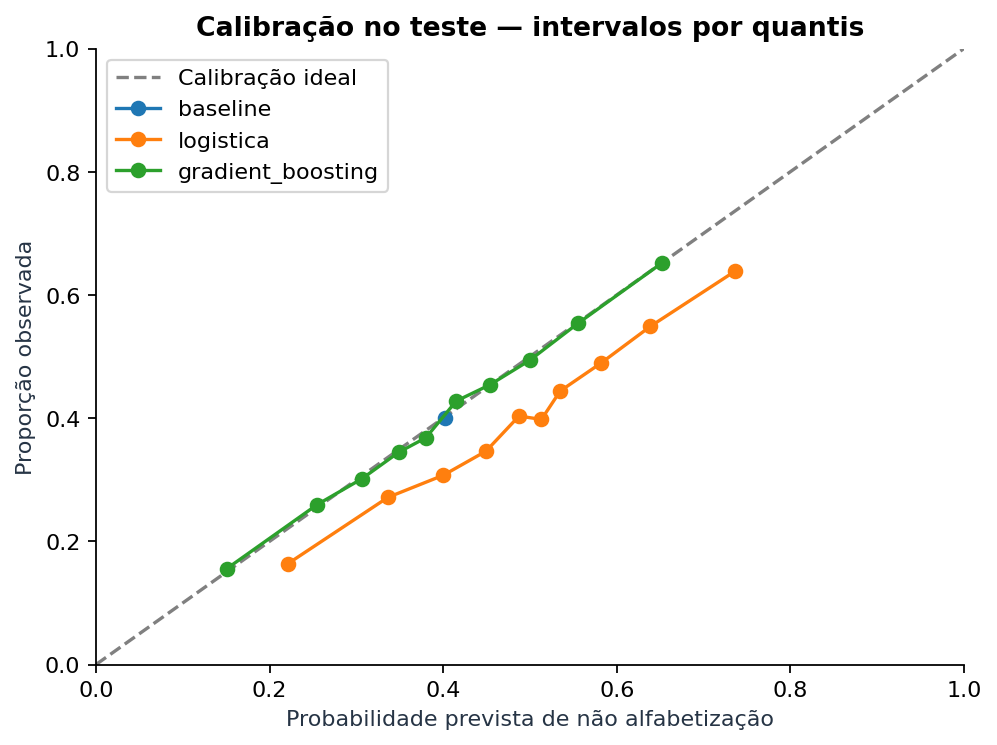

In [9]:
metricas = ["acuracia", "f1_macro", "recall_risco", "precisao_risco", "roc_auc", "brier"]
display(pd.DataFrame(resultados["teste"]).T[metricas].round(4))
display(resultados["incerteza_escolas"])
figura("teste_confusao.png")
figura("teste_curvas.png")
figura("teste_calibracao.png")

O bootstrap reamostra escolas mantendo o modelo fixo. Não cobre toda a incerteza de treinamento e origem. A logística oferece sinal moderado e tende a superestimar risco: score médio não deve ser tratado como taxa municipal calibrada.

## 7. Interpretação

Permutação mede queda de F1 ao embaralhar cada variável. SHAP mede contribuição em log-odds da classe 0; categorias e indicadores são somados à variável original. Valores absolutos não mostram direção do efeito. Importância não demonstra causalidade.

,variavel,queda_f1_macro,desvio_permutacoes
0,taxa_alfabetizacao_municipio_anterior,0.037427,0.004754
1,rede,0.009668,0.001906
2,regiao_brasil,0.007500,0.003507
3,sigla_uf,-0.000046,0.001763
4,valor_medio_pagamento_bolsa_familia_anterior,-0.002260,0.000411
5,taxa_presenca_municipio_anterior,-0.002352,0.002348
6,valor_total_bolsa_familia_anterior,-0.004329,0.001575
7,total_pagamentos_bolsa_familia_anterior,-0.004356,0.001568
8,alunos_avaliados_municipio_anterior,-0.006505,0.002877


Erro máximo da reconstrução SHAP: 2.220446049250313e-16


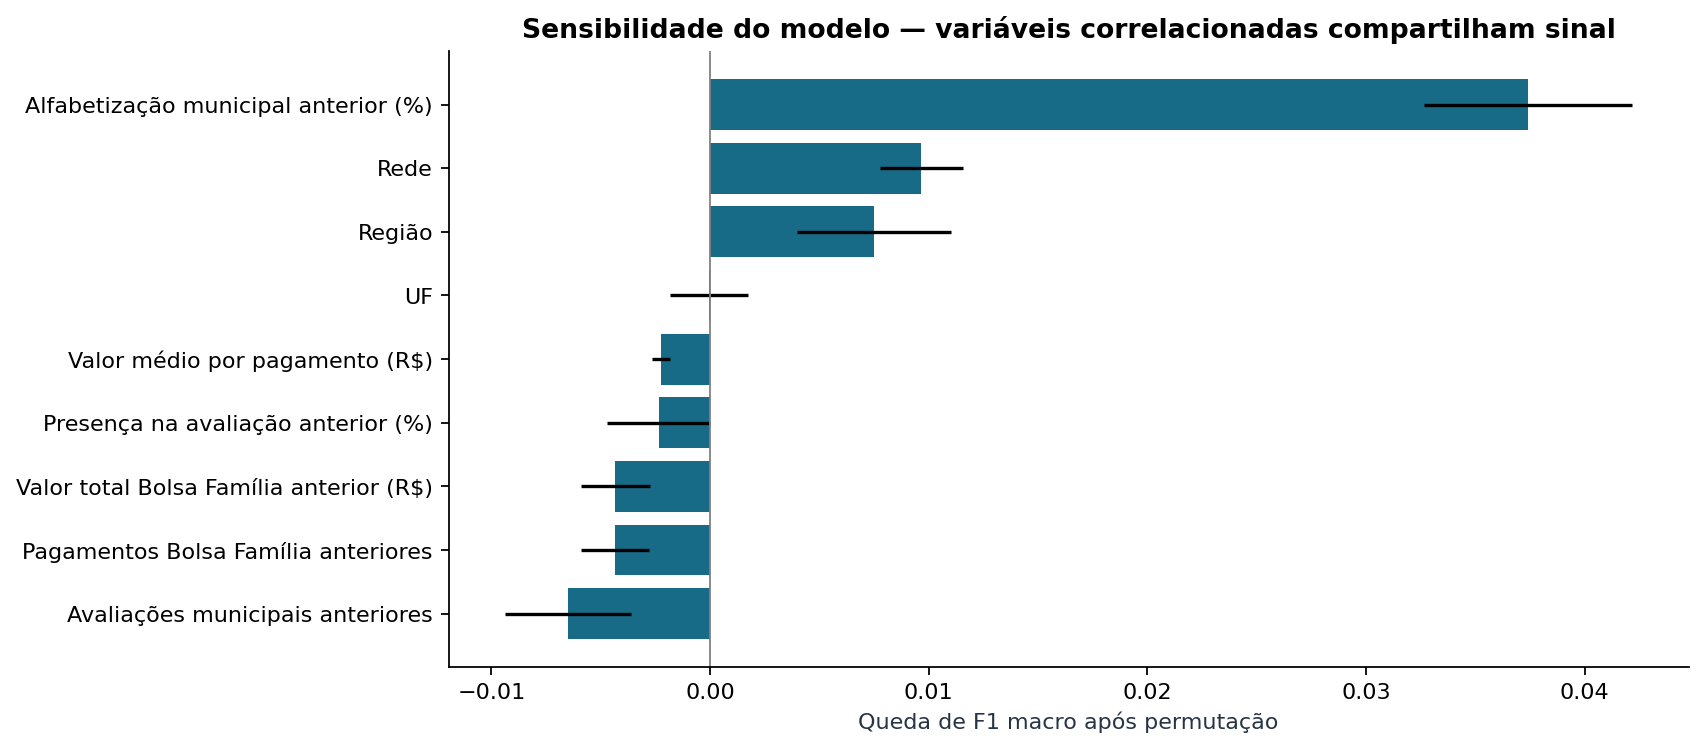

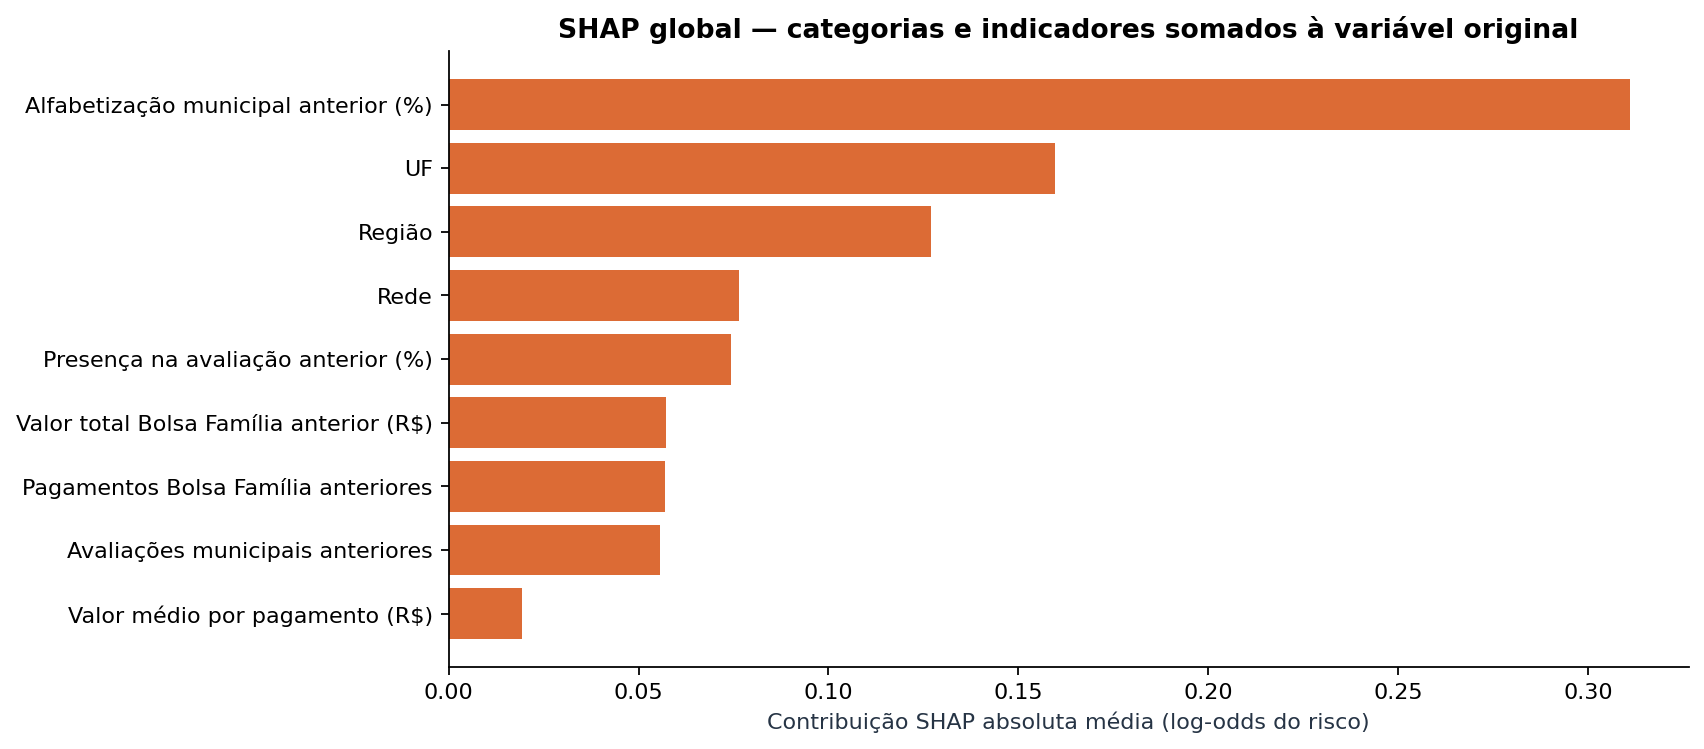

In [10]:
display(pd.DataFrame(interpretacao["permutacao"]))
print("Erro máximo da reconstrução SHAP:", interpretacao["erro_maximo_reconstrucao_probabilidade"])
figura("interpretacao_permutacao.png")
figura("interpretacao_shap.png")

O histórico municipal ocupa a primeira posição nos dois métodos. Atribuições de UF/região e de variáveis financeiras compartilham sinal. Importâncias negativas são reportadas, sem usar o teste para selecionar novamente as features.

## 8. Recortes e aplicação estratégica

Comparar médias nacionais esconde diferenças. No Norte, alto recall do risco acompanha baixo recall dos alfabetizados. Roraima não está incluída. A rede Privada tem amostra muito pequena, sinalizada nos relatórios.

,grupo,n,prevalencia_risco,f1_macro,recall_risco,recall_alfabetizado
0,Centro-Oeste,35594,0.3617,0.5618,0.3555,0.7688
1,Nordeste,94115,0.4290,0.6321,0.7450,0.5473
2,Norte,39551,0.4943,0.4664,0.9008,0.1757
3,Sudeste,145705,0.3704,0.5694,0.5635,0.5911
4,Sul,54241,0.3919,0.6225,0.5370,0.7075


amostra de escolas do teste; scores sem recalibração e sem ponderação; não estima taxa municipal ou resultado futuro. **Filtro:** pelo menos 100 avaliações e 3 escolas no teste por município/rede.

,id_municipio_nome,sigla_uf,rede,avaliacoes_teste,escolas_teste,score_risco_medio
0,Araci,BA,Municipal,112,3,0.816054
1,Paulo Afonso,BA,Municipal,343,7,0.811487
2,Porto Alegre,RS,Municipal,399,7,0.810054
3,Feira de Santana,BA,Municipal,711,19,0.795939
4,Remanso,BA,Municipal,105,4,0.794949
5,Muritiba,BA,Municipal,102,3,0.793860
6,Alvorada,RS,Municipal,262,5,0.792832
7,Sento Sé,BA,Municipal,113,5,0.783271
8,Lauro de Freitas,BA,Municipal,191,6,0.782752
9,Pelotas,RS,Municipal,219,9,0.780526


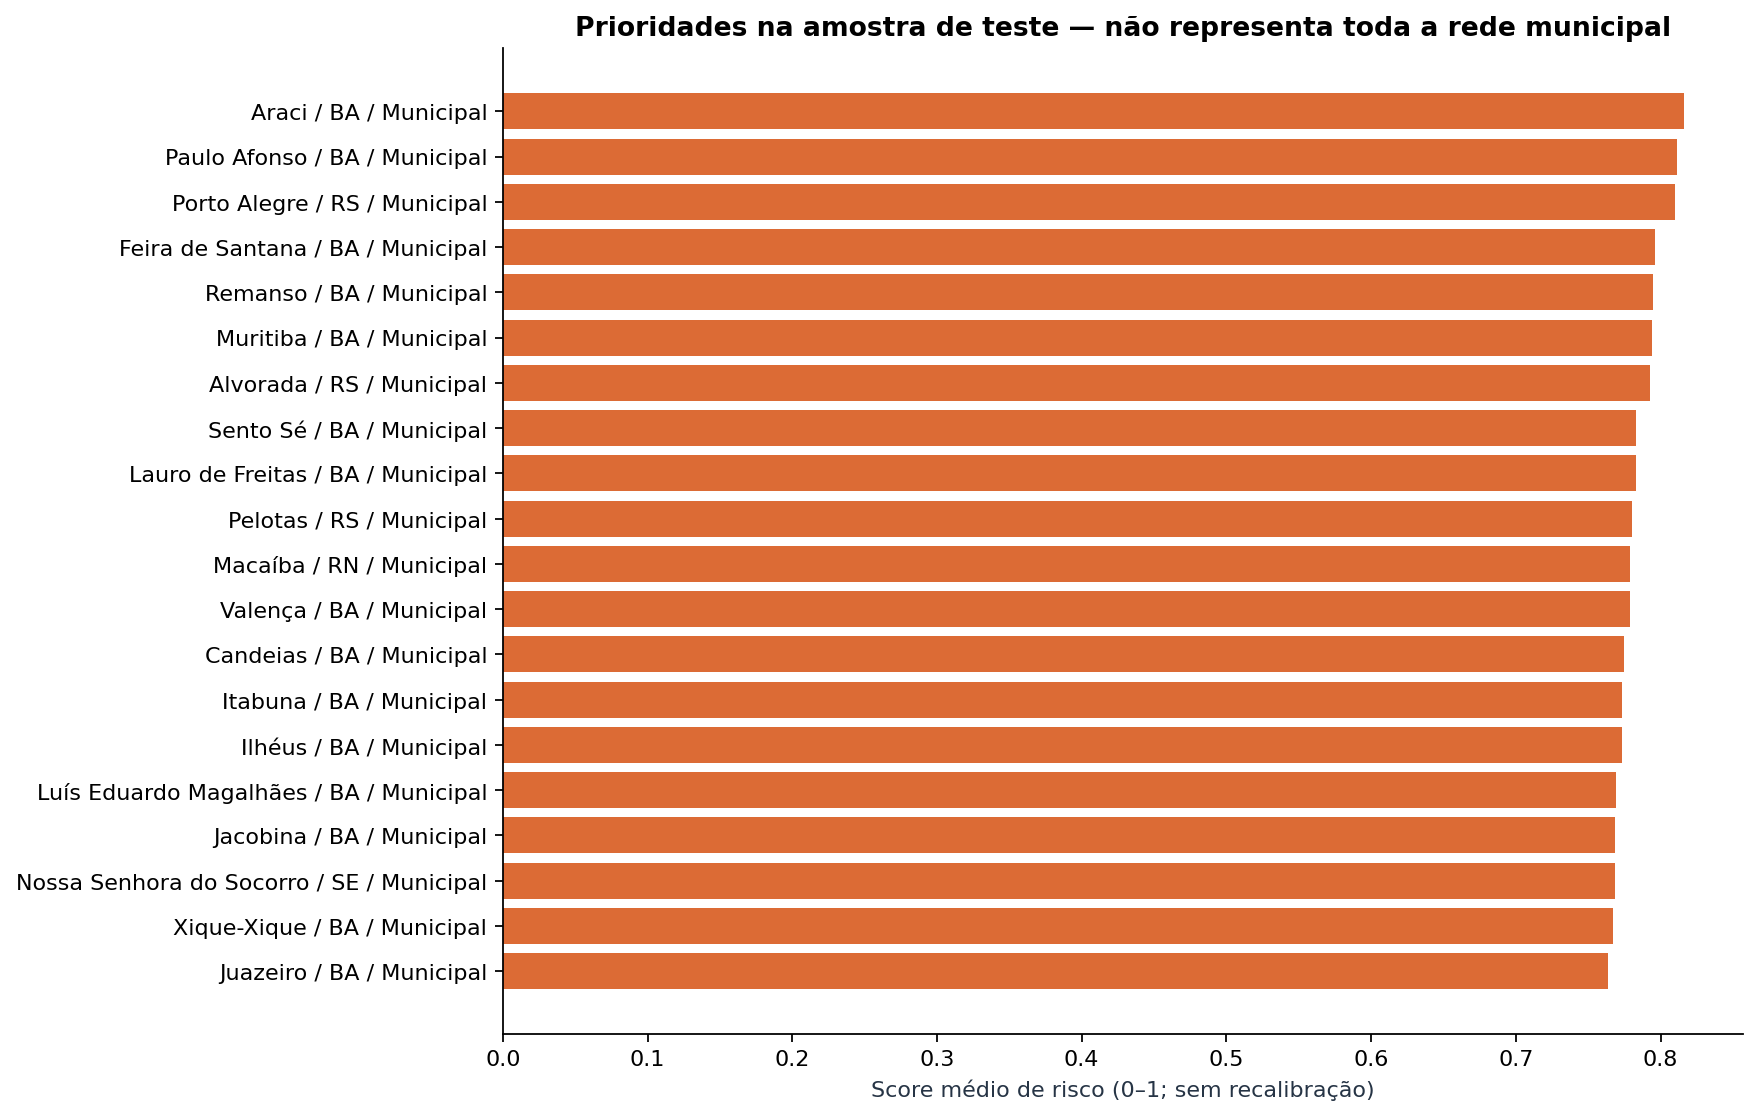

In [11]:
display(pd.DataFrame(resultados["recortes_teste"]["regiao_brasil"])[
    ["grupo", "n", "prevalencia_risco", "f1_macro", "recall_risco", "recall_alfabetizado"]].round(4))
ranking = ler("priorizacao_amostra_teste.json")
display(Markdown(ranking["escopo"] + ". **Filtro:** " + ranking["filtro"] + "."))
display(pd.DataFrame(ranking["top20"])[
    ["id_municipio_nome", "sigla_uf", "rede", "avaliacoes_teste", "escolas_teste", "score_risco_medio"]].head(10))
figura("prioridades_teste.png")

O ranking sugere onde aprofundar o diagnóstico local. Representa apenas escolas do teste e não prevê descumprimento de metas futuras. Não foi calculada uma distância da meta baseada em scores sem calibração.

Para gestores: conferir cobertura e dados locais, planejar apoio com as escolas e acompanhar resultados. O modelo contextual não sustenta rotular crianças nem atribuir causalidade a políticas sociais.

## 9. Próximo ciclo e reprodução

1. Integrar IBGE e Censo Escolar à Gold, com datas de disponibilidade.
2. Validar outra edição temporal e municípios novos.
3. Calibrar e escolher limiar no desenvolvimento, conforme a capacidade de atendimento.
4. Avaliar enriquecimentos/ablações em um novo protocolo, preservando um teste final.

Reproduzir na raiz do repositório:

```powershell
python -m pip install -r requirements.txt
python -m pytest tests/ -q
python main.py tudo
```

Documentação: [decisões](../reports/decisoes_analiticas.md), [aplicação estratégica](../reports/aplicacao_estrategica.md), [resultados](../reports/resultados.md) e [roteiro de vídeo](../reports/roteiro_video.md).

O grupo ainda precisa gravar o vídeo de até cinco minutos e realizar o PR/revisão colaborativa.